<a href="https://colab.research.google.com/github/Ashab-Uddin/Machine-Learning/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
First five rows of the dataset:
   study_hours  attendance_percentage  passed
0          4.4                   89.4       1
1          9.6                   94.3       1
2          7.6                   62.5       1
3          6.4                   51.1       0
4          2.4                   57.5       0
Dataset Shape: (120, 3)
Column Names:
Index(['study_hours', 'attendance_percentage', 'passed'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            120 non-null    float64
 1   attendance_percentage  120 non-null    float64
 2   passed                 120 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.9 KB

Descriptive 

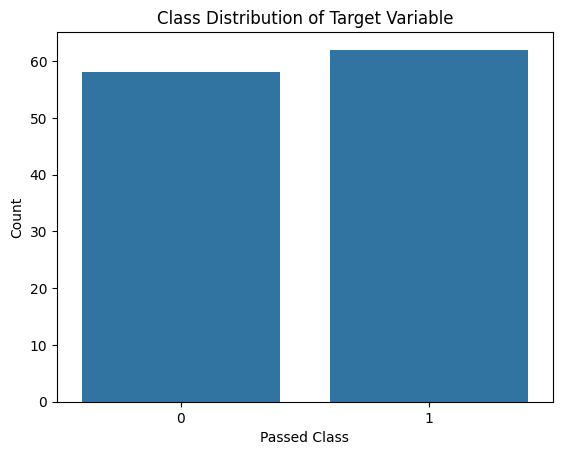

Shape of X: (120, 2)
Shape of y: (120,)
KNN model training completed successfully.
   Actual Class  Predicted Class
0             1                1
1             1                1
2             1                1
3             1                0
4             0                0
5             0                0
6             0                0
7             0                0
8             0                0
9             1                1
Accuracy: 0.8333333333333334

Confusion Matrix:
[[10  2]
 [ 2 10]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        12
           1       0.83      0.83      0.83        12

    accuracy                           0.83        24
   macro avg       0.83      0.83      0.83        24
weighted avg       0.83      0.83      0.83        24



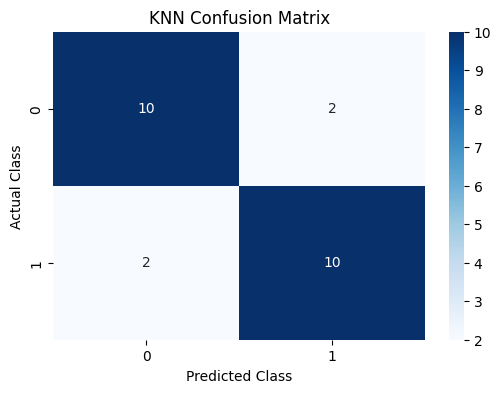

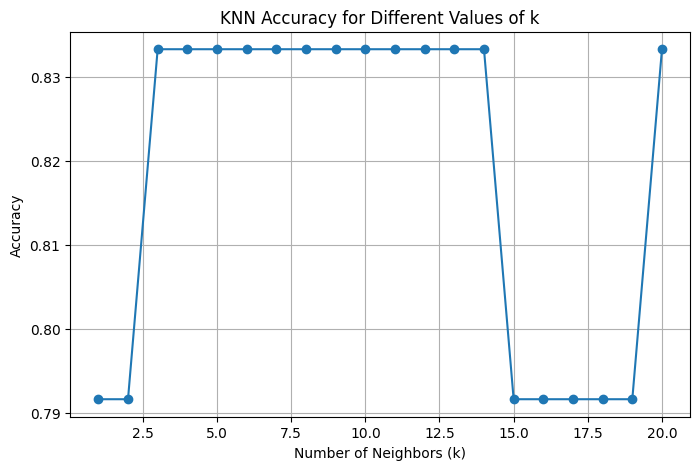

In [20]:

# Suppress warnings for cleaner output
from google.colab import drive
drive.mount('/content/drive/')
import warnings
warnings.filterwarnings('ignore')

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# Step 2: Load the KNN Dataset

path = '/content/drive/MyDrive/CSE404DemoData/knn_classification_dataset.csv'

# Load the dataset using the Pandas library
df = pd.read_csv(path)

# Display the first five rows
print("First five rows of the dataset:")
print(df.head())


# Step 3: Explore the Dataset

# Check dataset shape
print("Dataset Shape:", df.shape)

# Check column names
print("Column Names:")
print(df.columns)

# Check data types and missing values
print("\nDataset Information:")
df.info()

# Summary statistics
print("\nDescriptive Statistics:")
print(df.describe())


# Step 4: Check Class Distribution

# Check target class distribution
print("Class Distribution:")
print(df['passed'].value_counts())

# Visualize class distribution
sns.countplot(x='passed', data=df)
plt.title('Class Distribution of Target Variable')
plt.xlabel('Passed Class')
plt.ylabel('Count')
plt.show()


# Step 5: Select Input Features and Target Variable

# Select independent variables and dependent variable
X = df[['study_hours', 'attendance_percentage']]
y = df['passed']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


# Step 6: Split and Scale the Dataset

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature scaling is important for KNN
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Step 7: Create and Train the KNN Model

# Create KNN classifier
knn_model = KNeighborsClassifier(n_neighbors=7)

# Train the model
knn_model.fit(X_train_scaled, y_train)

print("KNN model training completed successfully.")


# Step 8: Make Predictions

# Predict class labels for test data
y_pred = knn_model.predict(X_test_scaled)

# Compare actual and predicted values
comparison_df = pd.DataFrame({
    'Actual Class': y_test.values,
    'Predicted Class': y_pred
})

print(comparison_df.head(10))


# Step 9: Evaluate the KNN Model

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(report)


# Step 10: Visualize Confusion Matrix

# Confusion matrix visualization
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('KNN Confusion Matrix')
plt.show()


# Step 11: Analyze Different Values of K

# Evaluate KNN for different values of k
k_values = range(1, 21)
accuracy_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train_scaled, y_train)

    predictions = model.predict(X_test_scaled)

    accuracy_scores.append(
        accuracy_score(y_test, predictions)
    )


# Plot k value vs accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    accuracy_scores,
    marker='o'
)

plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy for Different Values of k')
plt.grid(True)
plt.show()
